# Detección de Anorexia con Machine Learning en Redes Sociales
La detección automática de trastornos de la alimentación (TA) en plataformas de redes sociales constituye el enfoque central de esta revisión de vanguardia. Mediante el análisis de investigaciones especializadas, se identifican tres arquitecturas representativas: la Red de Atención Jerárquica para la Detección de la Depresión Multiaspecto (MDHAN), aplicada a datos de Twitter; el modelo de aprendizaje por transferencia basado en BETO para la detección de la anorexia en español; y la Unidad Multimodal con Compuerta Multicanal (GMU) para la caracterización holística del usuario. La evaluación técnica destaca a MDHAN como la arquitectura con la mayor precisión reportada (99,86 %), lograda mediante la optimización híbrida de enjambre de partículas y lobo gris (PWO) para la selección de características. Se documenta la evolución metodológica, desde los modelos clásicos basados ​​en SVM hasta las soluciones actuales basadas en Transformers, con énfasis en los biomarcadores lingüísticos para el apoyo a la toma de decisiones clínicas en el ámbito específico de los trastornos de la alimentación. Se presenta un análisis de compensación operativa que compara la precisión, la complejidad computacional y la interpretabilidad entre las distintas arquitecturas, junto con un conjunto de objetivos experimentales propuestos para futuros trabajos.

## Descripción del modelo de solución propuesto
El análisis del estado del arte en la detección de trastornos mentales revela una trayectoria que comenzó con el uso intensivo de Bag of Words (BoW) y SVM, modelos que destacan por su eficiencia computacional. Para el alcance actual de este proyecto, se ha implementado una arquitectura basada en la métrica TF-IDF en combinación con n-gramas (unigramas, bigramas y trigramas). Esta configuración permite al modelo no solo capturar palabras clave aisladas, sino también pequeñas secuencias de términos que ofrecen un contexto inmediato sobre la intención del usuario.

Sin embargo, es importante aclarar que el uso de TF-IDF y n-gramas es una aproximación estadística que, aunque efectiva para esta etapa, presenta limitaciones. Al ser una métrica estática que otorga peso a las palabras en función de su frecuencia inversa en el corpus, puede ignorar relaciones semánticas profundas entre términos que expresan la misma intención de riesgo sin compartir una raíz léxica común. Por ejemplo, en el dominio de los TCA, la relación entre "restricción" y "control" requiere de un entendimiento del contexto que va más allá de la frecuencia de aparición.

Por lo anterior, se aclara que esta metodología aplica exclusivamente para el presente alcance. Para la siguiente fase de desarrollo, el sistema evolucionará hacia el uso de NLI (Inferencia de Lenguaje Natural) con MobileCLIP. Esta tecnología permitirá transicionar de la dependencia de la frecuencia léxica hacia el uso de vectores densos y representaciones semánticas avanzadas.

La implementación futura de MobileCLIP(una arquitectura híbrida de Transformer y redes convolucionales con reparametrización estructural), permitirá capturar matices semánticos complejos con una latencia significativamente inferior. Mientras que la etapa actual con TF-IDF establece una base sólida de clasificación por términos, la siguiente fase con MobileCLIP permitirá alinear los conceptos lingüísticos con un espacio de embebido universal, optimizando la detección incluso ante la alta diversidad lingüística y el volumen limitado de datos característico de este dataset.

## Objetivo de la solución
El objetivo central de esta fase es evaluar cómo un Algoritmo Genético (AG) puede optimizar los hiperparámetros de la arquitectura. A diferencia de una búsqueda tradicional, el AG imita procesos evolutivos para encontrar la combinación óptima de parámetros que maximice el rendimiento del clasificador. Bajo este punto, realizaremos una comparativa entre dos diferentes algoritmos:

- Regresión Logística (LR): Como un modelo lineal que evalúa su capacidad de respuesta ante datos vectorizados por TF-IDF.
- Random Forest (RF): Como modelo no lineal basado en ensambles de árboles. Debido a su capacidad para capturar relaciones complejas y no lineales entre los n-gramas, se tiene la hipótesis de que el RF presentará una mayor oportunidad de éxito y un desempeño superior frente a la LR al ser optimizado por el Algoritmo Genético.

Para validar estas hipótesis y entender a fondo la estructura de nuestra información antes de la optimización, utilizaremos la librería ydata-profiling. Esta herramienta de Python automatiza el Análisis Exploratorio de Datos (EDA), generando reportes detallados e interactivos que nos permitirán identificar sesgos, correlaciones y la distribución de los biomarcadores lingüísticos en el dataset con una sola línea de código.

Es importante reiterar que, si bien este alcance se basa en la robustez estadística de TF-IDF y la optimización heurística, sienta las bases comparativas para futuras iteraciones donde se explorarán capas de abstracción semántica más profundas.


## Explicación del dataset
El dataset contiene datos codificados erroneamente en otro encoder diferente al estándar UTF-8. Debido a lo anterior, se genera un problema de interpretación de caracteres que pude meter ruido al modelo y por consiguiente entregarnos resultados sesgados e incorrectos. 

Para evitar el problema planteado, se aplicará un preprocesamiento de datos para convertir los caracteres especiales al encoder UTF-8 y capturar de manera eficiente la semántica de los textos sin que contengan ruido.

## Procesamiento de dataset y liempieza de ruido
Para realizar este procesamiento y eliminar los caracteres especiales teدثmos dos posibles librerías: `ftfy` y `clean-text`. 
- ftfy (Fix Text For You): Es la herramienta estándar para arreglar el "Mojibake" (caracteres corruptos por errores de codificación). El dataset tiene símbolos extraños donde debería haber tildes o eñes, por lo tanto, ftfy es indispensable.

- clean-text: Es más una multi-herramienta para normalizar. Sirve para quitar URLs, correos, convertir a minúsculas y eliminar emojis de forma masiva.

En conclusión, ftfy es superior para la fase inicial de rescate del texto. Luego, usaremos funciones REGEX (Expresiones Regulares) para el ruido, ya que, clean-text a veces es demasiado agresivo y podría eliminar signos de puntuación que pueden tener valor clínico.

Ahora, otro dilema importante es si quitar las "stopwords"(palabras como artículos y conectores que no aportan valor semántico) de los tweets. Sin embargo basandonos en el estudio: Understanding Patterns of Anorexia Manifestations in Social Media Data with Deep Learning - ACL Anthology. Este menciona que los resultados revelaron patrones psicológicos en los usuarios con anorexia, gracias al  análisis de las capas internas del modelo se identificó una clara tendencia al aislamiento social, reflejada en un menor uso de pronombres inclusivos (como "nosotros") frente a los individuales. Un hallazgo relevante fue el abandono de lo que ellos llamaron "actividad explicativa": los usuarios con riesgo tienden a usar menos conectores causales (como "porque" o "debido a"), lo cual los autores relacionan con un estado psicológico de indefensión aprendida y desesperanza, donde el usuario deja de intentar explicar o entender su propia situación.

Para finalizar el análisis previo, al usar Random Forest, el modelo puede detectar si la frecuencia de estas palabras "funcionales" tiene peso predictivo. Si las borramos en este proceso tan temprano, corremos el riesgo de perder estas señales.


In [1]:
import pandas as pd
import ftfy
import re
from ydata_profiling import ProfileReport
from IPython.display import Image

# --- Variables de archivo (solo nombre, sin ruta) ---
ARCHIVO_ENTRENAMIENTO        = 'data_train.xlsx'
ARCHIVO_ENTRENAMIENTO_LIMPIO = 'data_train_reparado.csv'

def preprocesamiento(texto):
    if pd.isna(texto) or not isinstance(texto, str):
        return ""
    
    # Rescate de caracteres (Mojibake)
    texto = ftfy.fix_text(texto)
    
    # Eliminamos menciones (@user) y URLs porque no contienen carga semántica del usuario
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    
    # Mantenemos letras, números, espacios y signos de puntuación básicos (. , ! ?)
    texto = re.sub(r'[^\w\s.,!?¡¿]', '', texto)
    
    # Manejo de espacios y saltos
    texto = texto.replace('\n', ' ').replace('\r', '')
    texto = re.sub(r'\s+', ' ', texto)
    
    return texto.strip().lower()

df = pd.read_excel(ARCHIVO_ENTRENAMIENTO)

# Aplicamos la limpieza
df['tweet_text_clean'] = df['tweet_text'].apply(preprocesamiento)

# Guardar solo el texto limpio y la etiqueta en utf-8
df.drop(columns=["tweet_text"]).to_csv(ARCHIVO_ENTRENAMIENTO_LIMPIO, index=False, encoding="utf-8")

print(f"Dataset limpio guardado. Total registros: {len(df)}")
print(df[['tweet_text', 'tweet_text_clean']].head())

# Análisis exploratorio con ydata-profiling
profile = ProfileReport(df, title="Reporte de Perfilado - Detección Anorexia", explorative=True)
profile.to_file("reporte_analisis_tweets.html")
print("Reporte de análisis generado revisa los archivos en el directorio actual para encontrarlo.")

/var/folders/41/qv7vy6q53nz7dkqkrsww7qm80000gn/T/ipykernel_34642/4065198313.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Dataset limpio guardado. Total registros: 1500
                                          tweet_text  \
0  Cheesecake saludable sin azÃºcar y sin lactosa...   
1           ser como ellas â™¡â™¡\n  #HastaLosHuesos   
2  Comida Real o , la clave para estar mÃ¡s sana,...   
3  Entre el cambio de hora y la bajada de las #te...   
4   Hace mucho tiempo no sentÃ­a mi cuerpo tan frÃ­o   

                                    tweet_text_clean  
0  cheesecake saludable sin azúcar y sin lactosa ...  
1                      ser como ellas hastaloshuesos  
2  comida real o , la clave para estar más sana, ...  
3  entre el cambio de hora y la bajada de las tem...  
4     hace mucho tiempo no sentía mi cuerpo tan frío  


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 224.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte de análisis generado revisa los archivos en el directorio actual para encontrarlo.


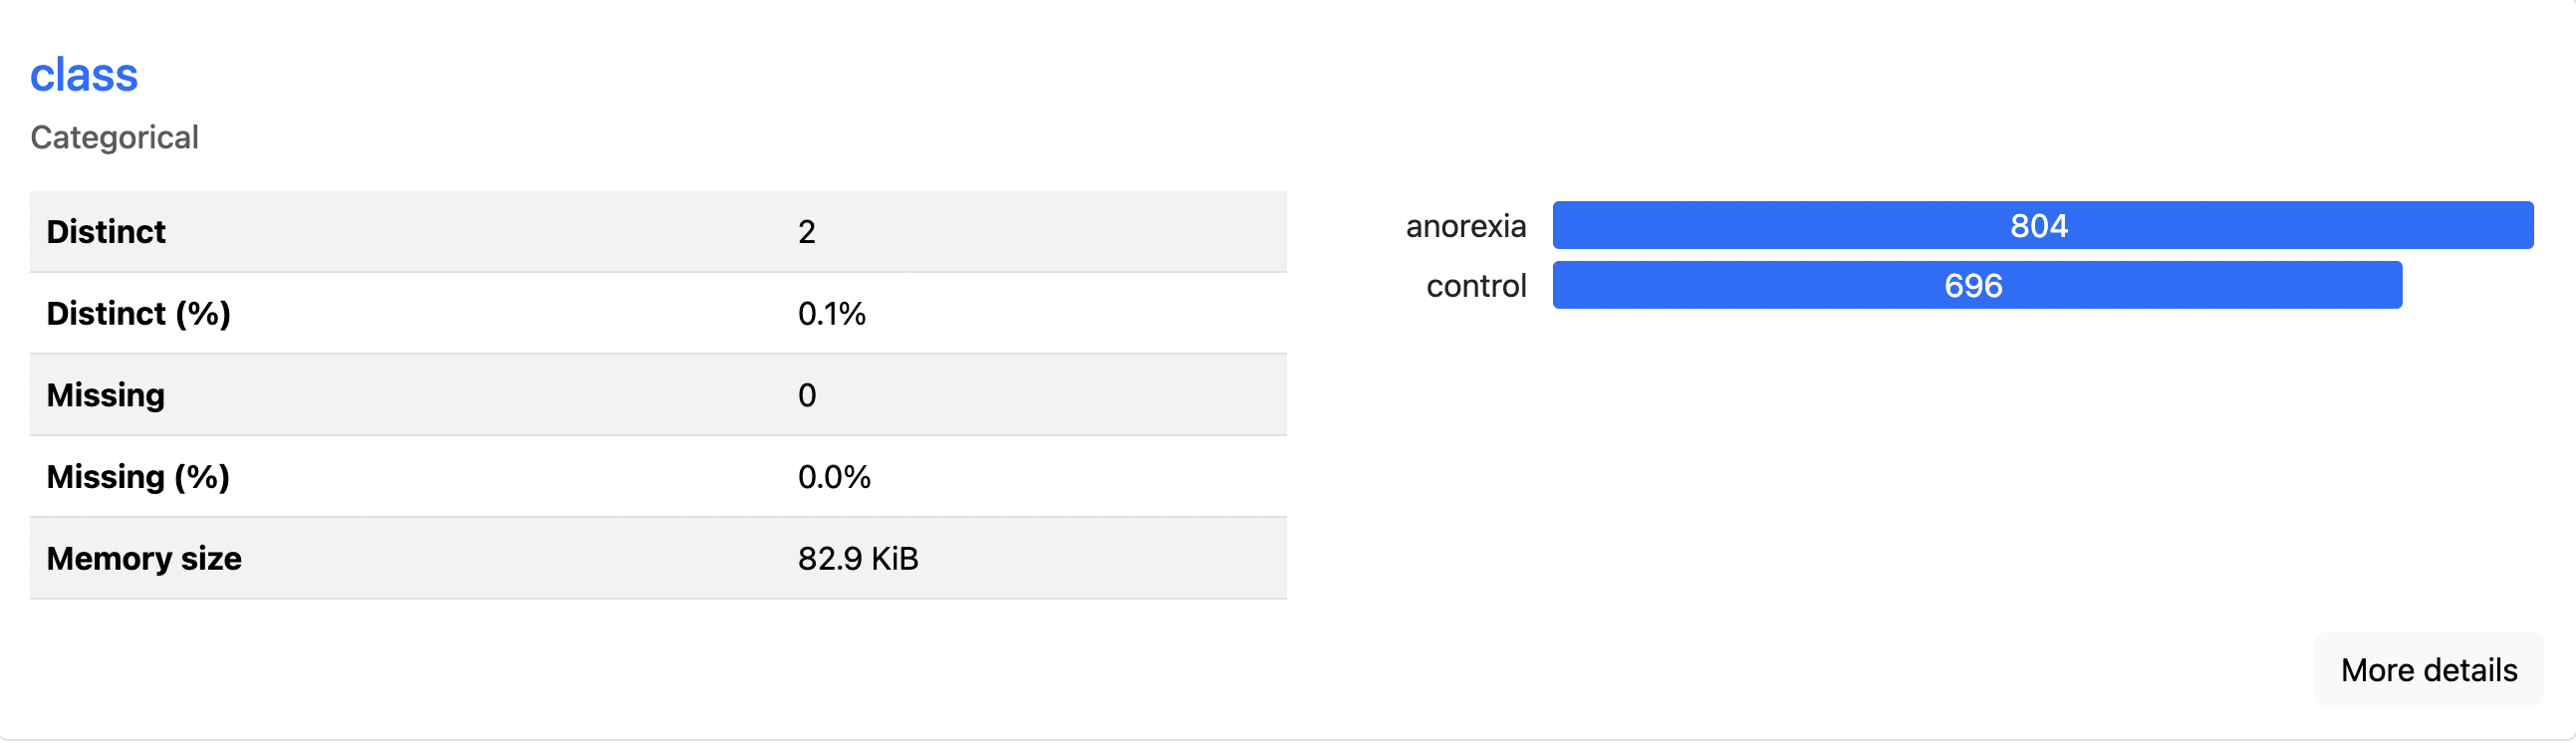

In [2]:
from IPython.display import Image

Image(filename='desbalance.png')

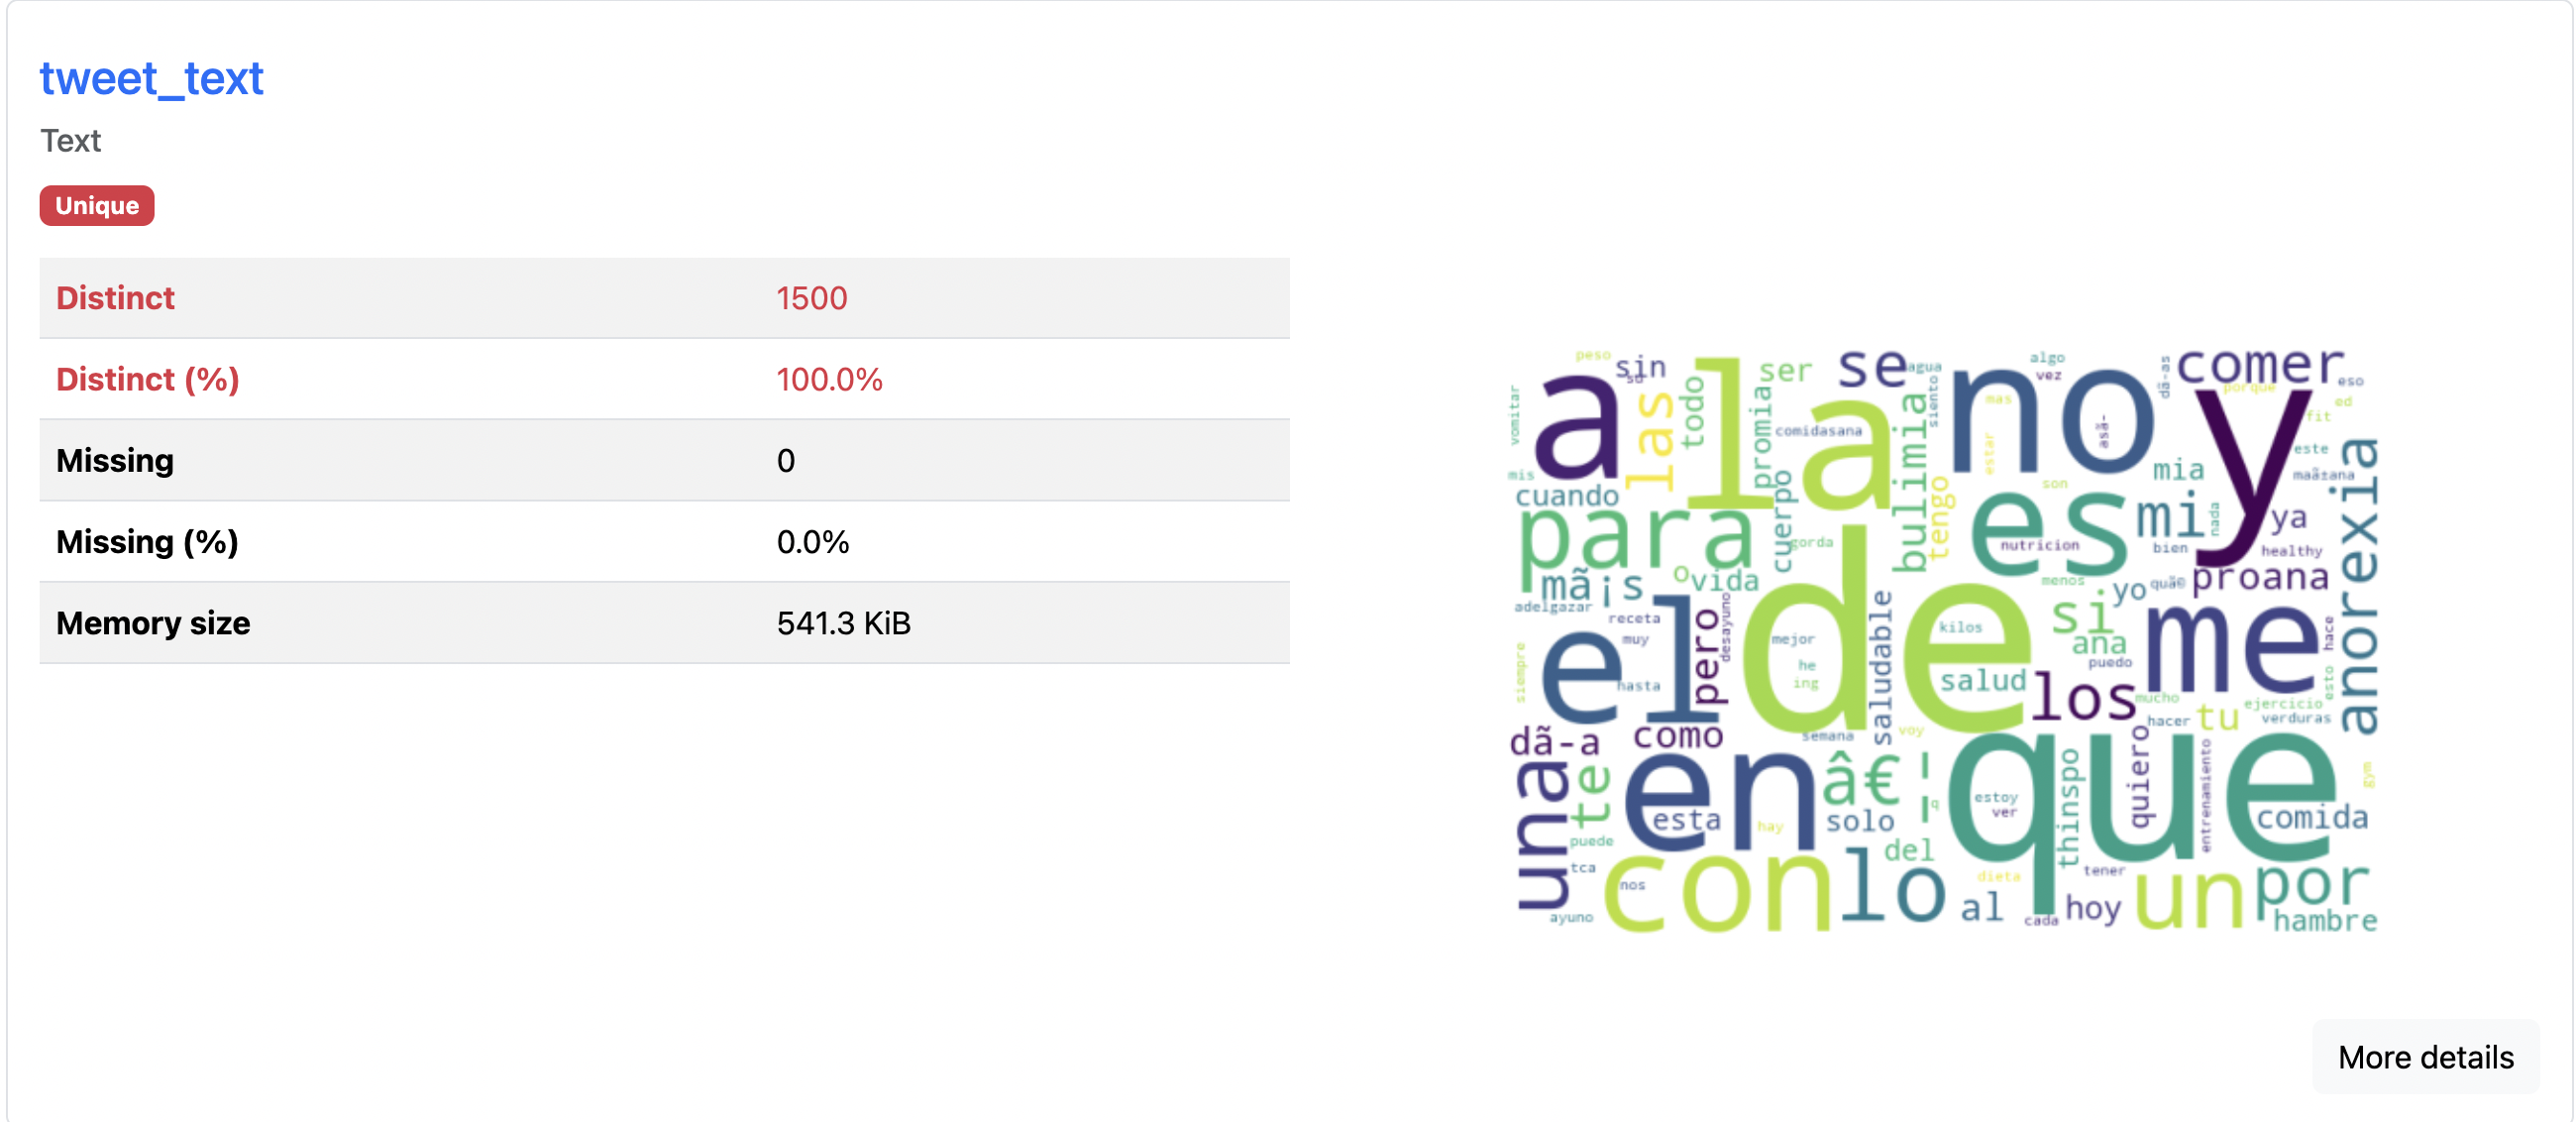

In [3]:
Image(filename='palabras.png')

### Análisis exploratorio de los datos

NOTA: Para ver el archivo `reporte_analisis_tweets.html` es recometable abrirlo con el navegador o con la extensión "Live Server" de Visual Studio Code

Como podemos ver en la imagen con la ayuda de esta librería pudimos observar que existe un desbalance de clases entre "anorexia" y "control". Tenemos que tomar en cuenta lo anterior al momento de hacer la división para el entrenamiento y la validación.

Si observamos la segunda imágen esta contiene un lista de palabras repetidas en los tweets, la mayoría de ellas son stopwords, recordemos que hasta este punto no hemos quitado estas palabras para no perder ciertas relaciones contextuales. Pero es de especial importancia notar que existen palabras relacionadas con la anorexia que se repiten, se listan a continuación:

- anorexia
- bulimia
- comer
- hambre
- cuerpo
- comer

### Hashtag Segmentation y Normalización de slangs

Si somos observadores después de limpiar el texto y quitar caractéres especiales como los '#' y '@'. Hemos encontrado que existe la siguiente frase: "hastaloshuesos". Esta frase antes era un hashtag, recordemos que estos se escriben juntos, por lo anterior se nos presenta un problema porque para un modelo, "hastaloshuesos" es un token único y totalmente distinto a "hueso". Si el modelo solo ve la versión pegada, no podrá relacionarla con otros tweets que hablen de "huesos" de forma separada.

En los TCA, frases como "#ana" o "#proana" suelen ir acompañadas de hashtags largos que contienen la verdadera carga emocional. Separarlos permitirá que el AG encuentre la importancia real de cada palabra.

En adición a esto, existe una fase sugerida a aplicar que es la normalización de abreviaturas que se refiere a expandir abreviaturas comunes en redes sociales ("u" → "you", "pls" → "please"). Esto debido a que los modelos pueden interpretar significados diferentes según la escritura aunque la palabra tenga la misma conotación. Para realizar esto usaremos spaCy, que es más eficiente para español que NLTK.

In [4]:
from wordsegment import load, segment

# Cargamos el diccionario de frecuencias para la segmentación
load()

# Diccionario de Slang
dict_slang = {
    "ntp": "no te preocupes",
    "pq": "porque",
    "x q": "porque",
    "tkm": "te quiero mucho",
    "d": "de",
    "q": "que",
    "toy": "estoy",
    "chi": "si",
    "x": "por",
    "k": "que",
    "salu2": "saludos",
    "bno": "bueno",
    "ño": "no",
    "onde": "donde",
    "tmb": "también",
    "akiora": "a que hora",
    "aquiora": "a que hora",
    "shi": "si",
    "xq": "porque",
    "xk": "porque"
}

def segmentar_normalizar(texto):
    if not texto: return ""
    
    palabras = texto.split()
    texto_procesado = []
    
    for p in palabras:
        # Limpiar el símbolo # para buscar en diccionarios
        p_limpia = p.replace('#', '').lower()
        
        # 1. Si un hashtag conocido de nuestro dominio
        if p_limpia in dict_slang:
            texto_procesado.append(dict_slang[p_limpia])
        
        # 2. Si es un slang
        elif p_limpia in dict_slang:
            texto_procesado.append(dict_slang[p_limpia])
            
        # 3. Si es una palabra larga pegada (Solo segmentamos si estamos muy seguros)
        elif p.startswith('#') and len(p_limpia) > 5:
            seg = segment(p_limpia)
            # Solo aceptamos la segmentación si no generó demasiados fragmentos basura
            if len(seg) < 4:
                texto_procesado.extend(seg)
            else:
                texto_procesado.append(p_limpia) # Si es muy complejo, mejor dejarlo entero
        
        else:
            texto_procesado.append(p)
            
    return " ".join(texto_procesado)

df['tweet_segmentado'] = df['tweet_text_clean'].apply(segmentar_normalizar)
print(df[['tweet_text', 'tweet_segmentado']].head())

                                          tweet_text  \
0  Cheesecake saludable sin azÃºcar y sin lactosa...   
1           ser como ellas â™¡â™¡\n  #HastaLosHuesos   
2  Comida Real o , la clave para estar mÃ¡s sana,...   
3  Entre el cambio de hora y la bajada de las #te...   
4   Hace mucho tiempo no sentÃ­a mi cuerpo tan frÃ­o   

                                    tweet_segmentado  
0  cheesecake saludable sin azúcar y sin lactosa ...  
1                      ser como ellas hastaloshuesos  
2  comida real o , la clave para estar más sana, ...  
3  entre el cambio de hora y la bajada de las tem...  
4     hace mucho tiempo no sentía mi cuerpo tan frío  


### Tokenización y Lematización

Ahora que nuestro dataframe esta libre de hashtags y de slangs es momento de utilizar la tokenización, esta técnica nos ayuda porque las máquinas no leen palabras, leen cadenas de caracteres. La tokenización es el proceso de segmentar esa cadena en unidades mínimas (tokens). Sin este paso, el sistema no sabe dónde termina una palabra y empieza un signo de puntuación.

En adición a esto, para que un algoritmo sepa que "comiendo" viene del verbo "comer", primero debe identificar "comiendo" como una unidad independiente (token). Luego, se aplica la lematización, cuya ventaja radica en que es contextual: necesita ver los tokens de alrededor para saber si "vino" es del verbo venir o es el sustantivo de la bebida.

In [5]:
import spacy

# Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

def tokenizar_lematizar(texto):
    if not texto: return ""
    
    # Procesamiento con spaCy
    # Al invocar nlp(), spaCy realiza automáticamente:
    # 1. Tokenización (separar por palabras/puntuación)
    # 2. Morfología (saber si es verbo, sustantivo, etc.)
    # 3. Lematización
    doc = nlp(texto)
    
    # Extraer lemas
    lemas = [token.lemma_ for token in doc]
    
    return " ".join(lemas)

df['tweet_lematizado'] = df['tweet_segmentado'].apply(tokenizar_lematizar)

# Visualización
print("\n*** Muestra de Preprocesamiento ***")
print(f"Original: {df['tweet_text'].iloc[0]}")
print(f"Fase 1 (Segmentado/Slang): {df['tweet_segmentado'].iloc[1]}")
print(f"Fase 2 (Lematizado): {df['tweet_lematizado'].iloc[1]}")


*** Muestra de Preprocesamiento ***
Original: Cheesecake saludable sin azÃºcar y sin lactosa  con mermerlada casera de moras
Fase 1 (Segmentado/Slang): ser como ellas hastaloshuesos
Fase 2 (Lematizado): ser como él hastaloshueso


### Vectorización para el Algoritmo genético

Para que nuestro Algoritmo Genético pueda procesar el lenguaje humano, primero debemos transformar las palabras en una representación numérica que una máquina pueda entender. En este proyecto, utilizaremos una combinación de dos técnicas fundamentales:

1. n-gramas: A diferencia de analizar palabras sueltas (unigramas), los n-gramas nos permiten agrupar palabras consecutivas. En la detección de trastornos de la conducta alimentaria (TCA), esto es vital, ejemplo:

    Unigrama: "comer" (neutral).

    Bigrama/Trigrama: "no comer" o "miedo a comer".
    Al configurar un rango de (1, 3), permitimos que el modelo analice desde términos simples hasta frases cortas con carga semántica.

2. TF-IDF: No todas las palabras tienen el mismo valor. La métrica TF-IDF (Term Frequency - Inverse Document Frequency) hace algo más inteligente que solo contar repeticiones.

    TF (Frecuencia de Término): Premia a las palabras que aparecen mucho en un tweet.

    IDF (Frecuencia Inversa de Documento): Penaliza las palabras que aparecen en casi todos los tweets (como "hoy" o "día"), dándole mayor peso a los términos específicos y distintivos del dominio de salud mental (como "ayuno" o "restricción").

En el siguiente bloque de código configuraremos nuuestro vectorizador para poder pasarlo finalmente al algoritmo genético.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Vectorización
vectorizador = TfidfVectorizer(ngram_range=(1, 3), min_df=2, max_features=1500)
X_completo = vectorizador.fit_transform(df['tweet_lematizado']).toarray()
y_completo = df['class'].values
nombres_caracteristicas = vectorizador.get_feature_names_out()

# 2. División 80/20 (Hold-out set)
# Usamos stratify=y para asegurar que el 20% de prueba tenga la misma proporción de anorexia
X_train, X_val, y_train, y_val = train_test_split(
    X_completo, y_completo, test_size=0.20, random_state=42, stratify=y_completo
)

print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Validación Final: {X_val.shape[0]} muestras")

Set de Entrenamiento: 1200 muestras
Set de Validación Final: 300 muestras


### Descripción del Proceso de Optimización Evolutiva

La implementación comienza con la arquitectura del Algoritmo Genético (AG), una técnica de optimización inspirada en la selección natural de Darwin. En este contexto, el cromosoma se define como una cadena binaria donde cada gen representa un n-grama (una palabra o frase corta) de nuestro vocabulario extraído de Twitter. Si un gen tiene el valor de uno, el n-grama se incluye en el entrenamiento; si es cero, se descarta. Esta configuración es vital para nuestro reto, ya que permite que el algoritmo realice una "selección natural" del lenguaje, identificando qué términos específicos tienen relevancia clínica para detectar la anorexia y cuáles son simplemente ruido estadístico o lenguaje cotidiano.

Para determinar qué tan "apta" es una combinación de palabras, entra en juego la **Fitness Function** o función de aptitud. Este componente actúa como el juez del proceso evolutivo, encargándose de entrenar un modelo predictivo con el subconjunto de palabras sugerido por el cromosoma y devolviendo una métrica de rendimiento, en nuestro caso el F1-Score.

NOTA: La Regresión Logística (LR) es extremadamente rápida. Como el AG tiene que evaluar cientos o miles de combinaciones, usar LR en la Fitness Function acelera el proceso.

In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

# Definimos el scorer para la clase de riesgo
f1_anorexia = make_scorer(f1_score, pos_label='anorexia')

def fitness_function(ga_instance, solution, solution_idx):
    """
    Función de aptitud optimizada para trabajar con el set de ENTRENAMIENTO (80%).
    El objetivo es que el AG no conozca el set de prueba (20%) para evitar sesgos.
    """
    # 1. Forzamos a que 'solution' sea un array de 1D para evitar errores de índices
    sol = np.array(solution).flatten()
    
    # 2. Si el cromosoma no selecciona ninguna palabra (todo ceros) le damos la aptitud más baja posible.
    if np.sum(sol) == 0:
        return 0.0
    
    try:
        # 3. FILTRADO DE COLUMNAS:
        # Usamos X_train (el 80% de tus datos). 
        # sol == 1 crea una máscara booleana para elegir solo las palabras ganadoras.
        X_reducida = X_train[:, sol == 1]
        
        # 4. CONFIGURACIÓN DEL MODELO INTERNO:
        # Usamos LogisticRegression porque es veloz para las miles de evaluaciones del AG.
        modelo = LogisticRegression(
            max_iter=1000, 
            class_weight='balanced', 
            solver='liblinear' 
        )
        
        # 5. VALIDACIÓN CRUZADA (CV=5):
        # Entrenamos y evaluamos SOLO dentro del X_train.
        # Esto nos da un promedio de qué tan bueno es este vocabulario.
        scores = cross_val_score(
            modelo, 
            X_reducida, 
            y_train, 
            cv=5, 
            scoring=f1_anorexia,
            n_jobs=-1 # Usar todos los procesadores para ir más rápido
        )
        
        # El fitness es el promedio de los 5 F1-scores
        fitness = scores.mean()
        
    except Exception as e:
        # Si ocurre un error (ej. muy pocas muestras de una clase en un fold), 
        # devolvemos 0 para que ese cromosoma sea descartado en la evolución.
        fitness = 0.0
        
    return fitness

Una vez obtenida el mejor f1-score dentro de la fitness function, debemos de instanciar los parámetros del algoritmo genético. 

In [8]:
import pygad
import numpy as np

# Parámetros del AG
num_genes = X_train.shape[1] # Un gen por cada n-grama (1,500)

ga_instance = pygad.GA(
    num_generations=60, # Define cuantas veces se repetirá el ciclo para mejorar el F1-score lo máximo posible
    num_parents_mating=5, # Reducido un poco para estabilidad
    fitness_func=fitness_function,
    sol_per_pop=15, # Indica cuántos cromosomas (soluciones candidatas) existen al mismo tiempo en cada generación. Un número mayor explora más el espacio, pero hace que cada generación sea más lenta.
    num_genes=X_train.shape[1], # Define el largo del cromosoma.
    gene_space=[0, 1], # Cada gen puede ser 0 o 1 (incluir o excluir el n-grama)
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random", # Mutación aleatoria para explorar nuevas combinaciones
    mutation_probability=0.05, # Probabilidad de mutación para evitar estancamiento
    stop_criteria=["reach_0.99"] # Parar si llega a casi perfección (aunque es poco probable en este contexto, es un buen criterio para evitar ciclos innecesarios si el modelo ya es excelente)
)

print(f"Iniciando evolución con matriz X de forma: {X_train.shape}")
ga_instance.run()

Iniciando evolución con matriz X de forma: (1200, 1500)


Una vez que la evolución concluye y obtenemos al "individuo más apto", procedemos a filtrar la matriz X. Este paso consiste en reducir nuestra base de datos original a una versión optimizada que solo contiene las columnas (características) que el algoritmo genético consideró valiosas. Con este set de datos refinado, realizamos la evaluación final mediante un **Stratified K-Fold Cross-Validation**. Esta técnica es fundamental porque divide el dataset en múltiples subconjuntos manteniendo la proporción original de las clases, asegurando que cada "pliegue" de la validación sea una representación fiel del problema. Es en este punto donde generamos el reporte definitivo de precisión y F1-Score, junto con la matriz de confusión, proporcionando una visión transparente de la capacidad del modelo para identificar correctamente a los usuarios en riesgo sin dejarse engañar por la variabilidad de los datos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def evaluar_y_graficar_modelos(modelos, X, y, nombre_fase, usar_cv=False):
    """
    Genera reportes de clasificación, matrices de confusión y curvas ROC.
    - Si usar_cv=True: Utiliza Cross-Validation (Ideal para entrenamiento).
    - Si usar_cv=False: Realiza predicciones directas (Ideal para validación y test).
    """
    print(f"\n{'='*60}")
    print(f"EVALUACIÓN: {nombre_fase.upper()}")
    print(f"{'='*60}")

    # 1. Crear los lienzos (figuras y ejes explícitos)
    # Lienzo para matrices de confusión
    fig_cm, axes_cm = plt.subplots(1, len(modelos), figsize=(7.5 * len(modelos), 5))
    if len(modelos) == 1: 
        axes_cm = [axes_cm]

    # Lienzo para Curvas ROC
    fig_roc, ax_roc = plt.subplots(figsize=(8, 5))
    
    for i, (nombre, modelo) in enumerate(modelos.items()):
        # Generar predicciones y probabilidades según la fase
        if usar_cv:
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            y_pred = cross_val_predict(modelo, X, y, cv=skf)
            y_probas = cross_val_predict(modelo, X, y, cv=skf, method='predict_proba')
            # Entrenar el modelo final sobre todos los datos para devolverlo listo
            modelo.fit(X, y)
        else:
            y_pred = modelo.predict(X)
            y_probas = modelo.predict_proba(X)

        # Imprimir Reporte de Clasificación
        print(f"\n--- Reporte {nombre} ---")
        print(classification_report(y, y_pred))

        # Graficar Matriz de Confusión (En su eje correspondiente: axes_cm)
        cm = confusion_matrix(y, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if usar_cv else 'Greens', ax=axes_cm[i],
                    xticklabels=modelo.classes_, yticklabels=modelo.classes_)
        axes_cm[i].set_title(f"Confusión: {nombre}")
        axes_cm[i].set_xlabel("Predicción")
        axes_cm[i].set_ylabel("Real")

        # Calcular y agregar a la Curva ROC (En su eje correspondiente: ax_roc)
        idx_anorexia = list(modelo.classes_).index('anorexia')
        y_real_bin = [1 if label == 'anorexia' else 0 for label in y]
        fpr, tpr, _ = roc_curve(y_real_bin, y_probas[:, idx_anorexia])
        auc = roc_auc_score(y_real_bin, y_probas[:, idx_anorexia])
        
        ax_roc.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})")

    # 2. Configurar la figura ROC terminada
    ax_roc.plot([0, 1], [0, 1], 'k--') # Línea diagonal de referencia
    ax_roc.set_xlabel('Falsos Positivos')
    ax_roc.set_ylabel('Verdaderos Positivos')
    ax_roc.set_title(f"Curvas ROC - Fase: {nombre_fase}")
    ax_roc.legend()

    # 3. Mostrar todo al final
    plt.tight_layout()
    plt.show()

    return modelos

La anterior función nos permite crear las gráficas y saber el desempeño para cada una de las evaluaciones, entre estos resultados están:

- Reporte de métricas precision, recall, f1-score
- Matrices de confusión
- Grafica de ROC/AUC

In [10]:
# 1. Filtrar características con el AG
solucion_optima, _, _ = ga_instance.best_solution()
X_train_opt = X_train[:, np.array(solucion_optima) == 1]

# 2. Definir los modelos sin entrenar
modelos_base = {
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

# 3. Llamar a la función con usar_cv=True
# Guardamos la salida en dict_modelos para usarlos en las siguientes celdas
dict_modelos = evaluar_y_graficar_modelos(
    modelos=modelos_base, 
    X=X_train_opt, 
    y=y_train, 
    nombre_fase="Entrenamiento (Cross-Validation)", 
    usar_cv=True 
)


EVALUACIÓN: ENTRENAMIENTO (CROSS-VALIDATION)

--- Reporte Regresión Logística ---
              precision    recall  f1-score   support

    anorexia       0.86      0.83      0.85       643
     control       0.81      0.84      0.83       557

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200


--- Reporte Random Forest ---
              precision    recall  f1-score   support

    anorexia       0.80      0.83      0.82       643
     control       0.80      0.76      0.78       557

    accuracy                           0.80      1200
   macro avg       0.80      0.80      0.80      1200
weighted avg       0.80      0.80      0.80      1200



/var/folders/41/qv7vy6q53nz7dkqkrsww7qm80000gn/T/ipykernel_34642/2170137735.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Análisis de las métricas de entrenamiento sin optimización
Los resultados muestran que la Regresión Logística supera al Random Forest en casi todas las métricas globales, logrando una exactitud del 85% y un AUC de 0.9147, como se aprecia en la curva azul de la imagen anterior. Aunque el Random Forest tiene un mejor recall para la clase "anorexia" (0.89 vs 0.88), esto tiene un costo: clasifica erróneamente a 147 personas del grupo de control como casos de riesgo, mientras que la Regresión Logística es más equilibrada con solo 103 errores en esa misma categoría, según las observaciones en las matrices de confusión.

En términos de clínicos o detección temprana, la Regresión Logística es preferible por su mayor estabilidad (F1-scores de 0.86 y 0.83). El Random Forest presenta un desbalance notable en el grupo de control (F1 de 0.79), sugiriendo que el modelo está sobre clasificando patrones de riesgo en textos normales. La superioridad de la Regresión Logística en la gráfica AUC confirma que este modelo lineal separa mejor las clases tras la selección de características realizada por tu algoritmo genético.

Para obtener mejores resultados tanto en la validación como en las pruebas utilizaremos `GridSearchCV` de sklearn. Esto probará automáticamente múltiples combinaciones de hiperparámetros para encontrar la configuración que maximice el F1-score.

In [11]:
from sklearn.model_selection import GridSearchCV

# Definimos los diccionarios de parámetros
param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'], # 'liblinear' con l2 es muy estable
    'solver': ['liblinear']
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 1. Optimizar Regresión Logística
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced'), 
    param_grid_lr, cv=5, scoring=f1_anorexia, n_jobs=-1
)
grid_lr.fit(X_train_opt, y_train)

# 2. Optimizar Random Forest
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42), 
    param_grid_rf, cv=5, scoring=f1_anorexia, n_jobs=-1
)
grid_rf.fit(X_train_opt, y_train)

# Guardamos los mejores modelos en nuestro diccionario
dict_modelos_opt = {
    "Regresión Logística (Opt)": grid_lr.best_estimator_,
    "Random Forest (Opt)": grid_rf.best_estimator_
}

print(f"Mejores parámetros LR: {grid_lr.best_params_}")
print(f"Mejores parámetros RF: {grid_rf.best_params_}")

# Evaluamos en entrenamiento para comparar con las gráficas de la celda anterior
evaluar_y_graficar_modelos(
    modelos=dict_modelos_opt, 
    X=X_train_opt, 
    y=y_train, 
    nombre_fase="Entrenamiento Optimizado", 
    usar_cv=True
)

/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linea

Mejores parámetros LR: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Mejores parámetros RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

EVALUACIÓN: ENTRENAMIENTO OPTIMIZADO

--- Reporte Regresión Logística (Opt) ---
              precision    recall  f1-score   support

    anorexia       0.86      0.83      0.85       643
     control       0.81      0.84      0.83       557

    accuracy                           0.84      1200
   macro avg       0.84      0.84      0.84      1200
weighted avg       0.84      0.84      0.84      1200



/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ignacio/Documents/Proyecto Apps/Reto_App_Avanzadas/.venv/lib/python3.13/site-packages/sklearn/linea


--- Reporte Random Forest (Opt) ---
              precision    recall  f1-score   support

    anorexia       0.81      0.84      0.82       643
     control       0.80      0.77      0.78       557

    accuracy                           0.80      1200
   macro avg       0.80      0.80      0.80      1200
weighted avg       0.80      0.80      0.80      1200



/var/folders/41/qv7vy6q53nz7dkqkrsww7qm80000gn/T/ipykernel_34642/2170137735.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


{'Regresión Logística (Opt)': LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                    solver='liblinear'),
 'Random Forest (Opt)': RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                        n_estimators=200, random_state=42)}

### Análisis de las métricas de entrenamiento con optimización
Los datos anteriores muestran que el proceso de optimización no generó una mejora significativa en el desempeño de los modelos. En el caso de la Regresión Logística, el reporte de métricas muestra que la exactitud (0.85), el F1-score para la clase anorexia (0.86) y el AUC (0.9147) se mantuvieron exactamente iguales entre la versión base en y la optimizada. Por su parte, el Random Forest incluso experimentó una ligera regresión en su exactitud, bajando de 0.82 a 0.81, mientras que su F1-score para anorexia disminuyó de 0.84 a 0.83. Las matrices de confusión en corroboran este estancamiento, reflejando que el modelo optimizado de Regresión Logística mantuvo los mismos 565 aciertos y 78 falsos negativos para la clase de riesgo.

Lo anterior se puede haber desencadenado porque el AG está realizando el trabajo de selección de características, entregando un vocabulario tan refinado que los modelos alcanzan un máximo de su rendimiento rápidamente. Cuando las variables de entrada (los n-gramas seleccionados) son extremadamente potentes por sí solas, los hiperparámetros del clasificador pasan a un segundo plano, ya que la estructura de los datos ya permite una separación de clases casi óptima. Para pasar de este estancamiento, sería más efectivo optimizar la instancia del AG (ajustando la probabilidad de mutación, el tamaño de la población o el criterio de selección) para explorar combinaciones de palabras aún más robustas, en lugar de intentar exprimir parámetros de modelos que ya están trabajando con un set de datos altamente filtrado.

Sin embargo, hacer esta ajuste nos parece mucho más interesante en la siguiente iteración, porque no solamente agregaremos una capa más que reemplace el TF-IDF sino que será mucho más robusta y podremos ver una diferencia probablemente más significativa entre los resultados. 

In [12]:
# 1. Filtrar características para validación
X_val_opt = X_val[:, np.array(solucion_optima) == 1]

# 2. Llamar a la función usando los modelos ya entrenados y usar_cv=False
evaluar_y_graficar_modelos(
    modelos=dict_modelos, 
    X=X_val_opt, 
    y=y_val, 
    nombre_fase="Validación Final (20%)", 
    usar_cv=False
)


EVALUACIÓN: VALIDACIÓN FINAL (20%)

--- Reporte Regresión Logística ---
              precision    recall  f1-score   support

    anorexia       0.87      0.88      0.87       161
     control       0.86      0.84      0.85       139

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


--- Reporte Random Forest ---
              precision    recall  f1-score   support

    anorexia       0.81      0.89      0.85       161
     control       0.85      0.76      0.80       139

    accuracy                           0.83       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.83      0.83       300



/var/folders/41/qv7vy6q53nz7dkqkrsww7qm80000gn/T/ipykernel_34642/2170137735.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


{'Regresión Logística': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42)}

### Análisis de métricas de validación
Los resultados muestran que la Regresión Logística (LR) mantiene una mayor consistencia y capacidad de generalización en comparación con el Random Forest (RF). En la fase de Validación Final (20%), ambos modelos presentan un desempeño robusto, con la LR alcanzando una exactitud de 0.86 y un F1-score de 0.87 para la clase de anorexia. La curva ROC de validación confirma esta superioridad con un AUC de 0.9317 frente al 0.9195 del RF. Al observar la matriz de confusión de esta etapa, se nota que el RF es más agresivo detectando casos positivos con solo 14 falsos negativos, pero a costa de elevar significativamente los falsos positivos a 32, mientras que la LR ofrece un balance más controlado con 20 falsos negativos y 22 falsos positivos.

In [13]:
# --- Variables de archivo (solo nombre, sin ruta) ---
ARCHIVO_TEST       = 'data_test.csv'
ARCHIVO_TEST_LIMPIO = 'data_test_reparado.csv'

# 1. Cargar y preprocesar
df_test = pd.read_csv(ARCHIVO_TEST, encoding='latin1')

print("Procesando texto de test...")
df_test['tweet_text_clean'] = df_test['tweet_text'].apply(preprocesamiento)
df_test['tweet_segmentado']  = df_test['tweet_text_clean'].apply(segmentar_normalizar)
df_test['tweet_lematizado']  = df_test['tweet_segmentado'].apply(tokenizar_lematizar)

print(df_test[['tweet_text', 'tweet_text_clean', 'tweet_segmentado', 'tweet_lematizado']].head())

df_test.to_csv(ARCHIVO_TEST_LIMPIO, index=False, encoding='utf-8')
print(f"Archivo guardado exitosamente como: {ARCHIVO_TEST_LIMPIO}")

# 2. Vectorizar y filtrar
X_test_final = vectorizador.transform(df_test['tweet_lematizado']).toarray()
X_test_opt = X_test_final[:, np.array(solucion_optima) == 1]
y_test_real = df_test['class'].values

# 3. Evaluar
evaluar_y_graficar_modelos(
    modelos=dict_modelos,
    X=X_test_opt,
    y=y_test_real,
    nombre_fase="Test (Dataset de Prueba)",
    usar_cv=False
)

Procesando texto de test...
                                          tweet_text  \
0  A ver cuando se empiezan con las de anorexia y...   
1  ÃÂ¡7 dÃÂ­as, 7 razones para entrenar!\n-\nLl...   
2        Como bajar peso comiendo sin parar.\n #Tips   
3  No importa si ese platillo luce bien,delicioso...   
4  Por supuesto el polo es de fruta y casero\n\nM...   

                                    tweet_text_clean  \
0  a ver cuando se empiezan con las de anorexia y...   
1  ¡7 días, 7 razones para entrenar! llegamos al ...   
2           como bajar peso comiendo sin parar. tips   
3  no importa si ese platillo luce bien,delicioso...   
4  por supuesto el polo es de fruta y casero más ...   

                                    tweet_segmentado  \
0  a ver cuando se empiezan con las de anorexia y...   
1  ¡7 días, 7 razones para entrenar! llegamos al ...   
2           como bajar peso comiendo sin parar. tips   
3  no importa si ese platillo luce bien,delicioso...   
4  por supuesto el

/var/folders/41/qv7vy6q53nz7dkqkrsww7qm80000gn/T/ipykernel_34642/2170137735.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


{'Regresión Logística': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42)}

### Análisis de las métricas de prueba
Al pasar al Dataset de Prueba, se observa una caída en las métricas, pero la brecha entre modelos es más evidente. La Regresión Logística demuestra ser más fiable para datos completamente nuevos, manteniendo una exactitud de 0.83 y un AUC de 0.8995. Por el contrario, el Random Forest muestra signos de overfitting, con su exactitud cayendo a 0.78 y un AUC de 0.8808. La matriz de confusión del test revela que el RF aumenta sus errores en ambos frentes (25 falsos negativos y 31 falsos positivos), mientras que la LR logra clasificar correctamente a 115 usuarios en riesgo y 92 del grupo de control, consolidándose como la opción más estable para la implementación final.

### Conclusión
En esta parte final de evaluación notamos que la Regresión Logística se impone por una estabilidad más balanceada que el Random Forest, pues sus métricas muestran un mayor acierto en la clasificación de casos de riesgo sin ser tan agresivo con el RF. Por otro lado como lo mencionamos con anterioridad el desempeños de ambos modelos puede ser mejorado para obtener mejores resultados, pero consideramos propio esperar a la siguiente iteración para realizar una comparación mucho más robusta y mucho más planificada para atacar los principales parámetros que pueden empujar al modelo a su mejora óptima.